# pyGAM malaria model selection — sandbox

Python/pyGAM recreation of the scam PfPR selection + downstream incidence/mortality
chain. The reusable logic lives in `idd_forecast_mbp.lib.modeling`
(`data`, `specs`, `fit`, `metrics`, `shift`, `summary`, `viz`) — this notebook is just the interactive surface.

- **Phase 1** — reproduce IS + the three OOS experiments (within / tempA / tempB) and the metric set.
- **Goal #1** — vary the formula / drop the country fixed effects.
- **Phase 3** — shift predicted PfPR to the observed 2023 anchor and feed it into the inc/mort models; score the whole chain.

In [1]:
# Auto-reload: edits to lib/modeling take effect on the next cell run (no kernel restart).
# NOTE: this reloads CODE, not data already in memory — after editing data.py, re-run the load cell.
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
from idd_forecast_mbp.lib.modeling import data, specs, fit, metrics, shift, summary, viz

## Phase 1 — load data + build the spec neighborhood

In [3]:
# 'modeled' = the scam selection row filter (inc_count >= 1 & pfpr >= 1e-4)
df = data.load_modeling_data(row_filter="modeled")
print(f"{len(df):,} rows, {df.A0_af.nunique()} countries, "
      f"years {int(df.year_id.min())}-{int(df.year_id.max())}")

neighborhood = specs.generate_specs()          # 270 specs by default (matches the R neighborhood)
print(f"{len(neighborhood)} specs; n_smooths:",
      pd.Series([specs.n_smooths(s) for s in neighborhood]).value_counts().sort_index().to_dict())

/ihme/homes/bcreiner/miniconda/envs/idd-forecast-mbp/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


164,225 rows, 70 countries, years 2000-2023
270 specs; n_smooths: {2: 24, 3: 76, 4: 94, 5: 57, 6: 17, 7: 2}


## Fit one spec across IS + the three OOS experiments

`fit.fit_predict` returns per-row predictions; `metrics.score_predictions` gives the
model-space and natural-space (`nat_*`) metric set — `nat_r` is the scam `oos_pfpr_r`.

In [4]:
pfpr_spec = (
    specs.Term("malaria_suit", "mpi", 6),
    specs.Term("gdppc_mean", "mpd", 6),
    specs.Term("mal_DAH_total_per_capita", "mpd", 6),
    specs.Term("logit_relative_humidity", "mpi", 6),
    specs.Term("A0_af", "factor"),
)
print(specs.spec_label(pfpr_spec))

rows = []
for ev, name in [("IS", "IS"), (fit.TEMP_A, "tempA"), (fit.TEMP_B, "tempB"), ("within", "within")]:
    res = fit.fit_predict(df, pfpr_spec, fit.PFPR, ev)
    rows.append({"eval": name, **metrics.score_predictions(res.predictions)})
pd.DataFrame(rows).set_index("eval")[["n_obs", "r_sq", "rmse", "nat_r", "nat_rmse"]]

s(malaria_suit, k=6, mpi) + s(gdppc_mean, k=6, mpd) + s(mal_DAH_total_per_capita, k=6, mpd) + s(logit_relative_humidity, k=6, mpi) + factor(A0_af)


,n_obs,r_sq,rmse,nat_r,nat_rmse
eval,,,,,
IS,164225,0.844089,1.179135,0.858731,0.101902
tempA,21972,0.810685,1.099464,0.819233,0.085548
tempB,21972,0.826817,1.051575,0.821976,0.080493
within,164225,0.843945,1.179680,0.858577,0.101954


In [5]:
base_spec = (specs.Term("mal_DAH_total_per_capita", "mpd", 6),
    specs.Term("logit_relative_humidity", "mpi", 6))

dim_terms = {
    "1D": (
            specs.Term("malaria_suit", "mpi", 6),
            specs.Term("gdppc_mean", "mpd", 6),
        ),
    "2D": (
            specs.Tensor(("malaria_suit", "gdppc_mean"), ("mpi", "mpd"), (6, 6)),  # 2D: suit↑, gdp↓, k=6 each
        )
}
FE_term = specs.Term("A0_af", "factor")

rows = []
fits = {}
for dim in ["1D", "2D"]:
    print(f"Fitting {dim} PFPR model...")
    for include_FE in [False, True]:
        FE_str = "with_FE" if include_FE else "without_FE"
        print(f"  {FE_str}...")
        name = f"{dim}_{FE_str}"
        spec = dim_terms[dim] + base_spec
        if include_FE:
            spec = spec + (FE_term,)
        res = fit.fit_predict(df, spec, fit.PFPR, "IS")
        fits[(dim, FE_str)] = res
        rows.append({"eval": name, **metrics.score_predictions(res.predictions)})
pd.DataFrame(rows).set_index("eval")[["n_obs", "r_sq", "rmse", "nat_r", "nat_rmse"]]

Fitting 1D PFPR model...
  without_FE...
  with_FE...
Fitting 2D PFPR model...
  without_FE...
  with_FE...


,n_obs,r_sq,rmse,nat_r,nat_rmse
eval,,,,,
1D_without_FE,164225,0.135565,2.776462,0.336349,0.220254
1D_with_FE,164225,0.844089,1.179135,0.858731,0.101902
2D_without_FE,164225,0.138855,2.771174,0.339390,0.219549
2D_with_FE,164225,0.844099,1.179100,0.858531,0.101975


In [7]:
# pfpr_1D_spec = (
#     specs.Term("malaria_suit", "mpi", 6),
#     specs.Term("gdppc_mean", "mpd", 6),
#     specs.Term("mal_DAH_total_per_capita", "mpd", 6),
#     specs.Term("logit_relative_humidity", "mpi", 6),
#     specs.Term("A0_af", "factor"),
# )
# pfpr_2D_spec =  (
#     specs.Tensor(("malaria_suit", "gdppc_mean"), ("mpi", "mpd"), (6, 6)),  # 2D: suit↑, gdp↓, k=6 each
#     specs.Term("mal_DAH_total_per_capita", "mpd", 6),
#     specs.Term("logit_relative_humidity", "mpi", 6),
#     specs.Term("A0_af", "factor"),
# )


# rows = []
# fits = {}
# for dim in ["1D", "2D"]:
#     print(f"Fitting {dim} PFPR model...")
#     for seach_type in ["no_search", "search"]:
#         print(f"  {seach_type}...")
#         name = f"{dim}_{seach_type}"
#         spec = pfpr_1D_spec if dim == "1D" else pfpr_2D_spec
#         if seach_type == "no_search":
#             res = fit.fit_predict(df, spec, fit.PFPR, "IS")
#         else: 
#             res = fit.fit_predict(df, spec, fit.PFPR, "IS", gridsearch=True)
#         fits[(dim, seach_type)] = res
#         rows.append({"eval": name, **metrics.score_predictions(res.predictions)})
# pd.DataFrame(rows).set_index("eval")[["n_obs", "r_sq", "rmse", "nat_r", "nat_rmse"]]

Text(0.5, 0, 'partial effect (logit)')

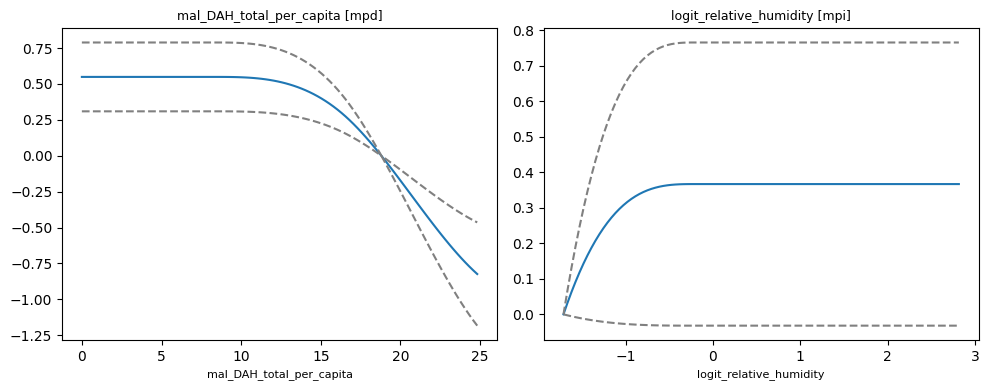

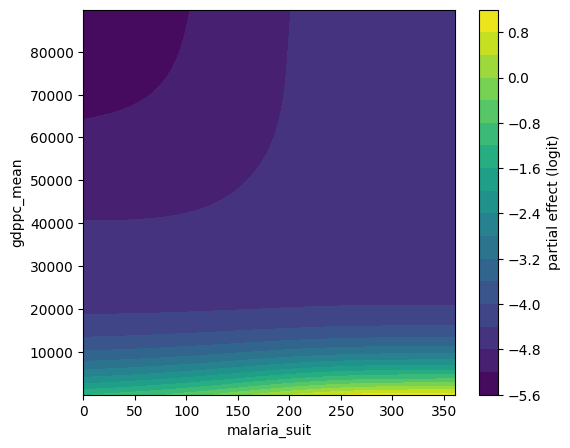

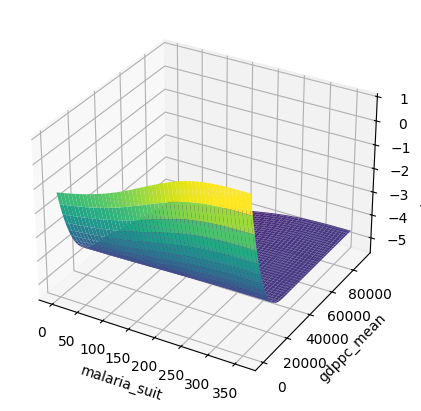

In [6]:
import matplotlib.pyplot as plt

dim = "2D"
include_FE = False
FE_str = "with_FE" if include_FE else "without_FE"
name = f"{dim}_{FE_str}"
spec = dim_terms[dim] + base_spec
if include_FE:
    spec = spec + (FE_term,)
res = fits[(dim, FE_str)]

gam = res.models[0]          # IS fit = full-data fit
# 1D smooths:
viz.plot_smooths(gam, spec, df)
# the 2D tensor surface: use the contourf/surface snippet with this gam
t  = next(i for i, e in enumerate(spec) if isinstance(e, specs.Tensor))  # tensor's term index
te = spec[t]
XX = gam.generate_X_grid(term=t, meshgrid=True)             # (100x100, 100x100)
Z  = gam.partial_dependence(term=t, X=XX, meshgrid=True)    # 100x100, logit scale

# (a) filled contour
fig, ax = plt.subplots(figsize=(6, 5))
cf = ax.contourf(XX[0], XX[1], Z, levels=20, cmap="viridis")
ax.set_xlabel(te.cols[0]); ax.set_ylabel(te.cols[1])
fig.colorbar(cf, label="partial effect (logit)")

# (b) 3D surface
fig = plt.figure(figsize=(6, 5)); ax = fig.add_subplot(projection="3d")
ax.plot_surface(XX[0], XX[1], Z, cmap="viridis")
ax.set_xlabel(te.cols[0]); ax.set_ylabel(te.cols[1]); ax.set_zlabel("partial effect (logit)")

### Plot the fitted smooths

`viz.plot_smooths` draws each `s()` term's partial dependence (link scale). Fit once on all
data with `fit.fit_gam`; pass `df` so the country factor is held at a valid level.

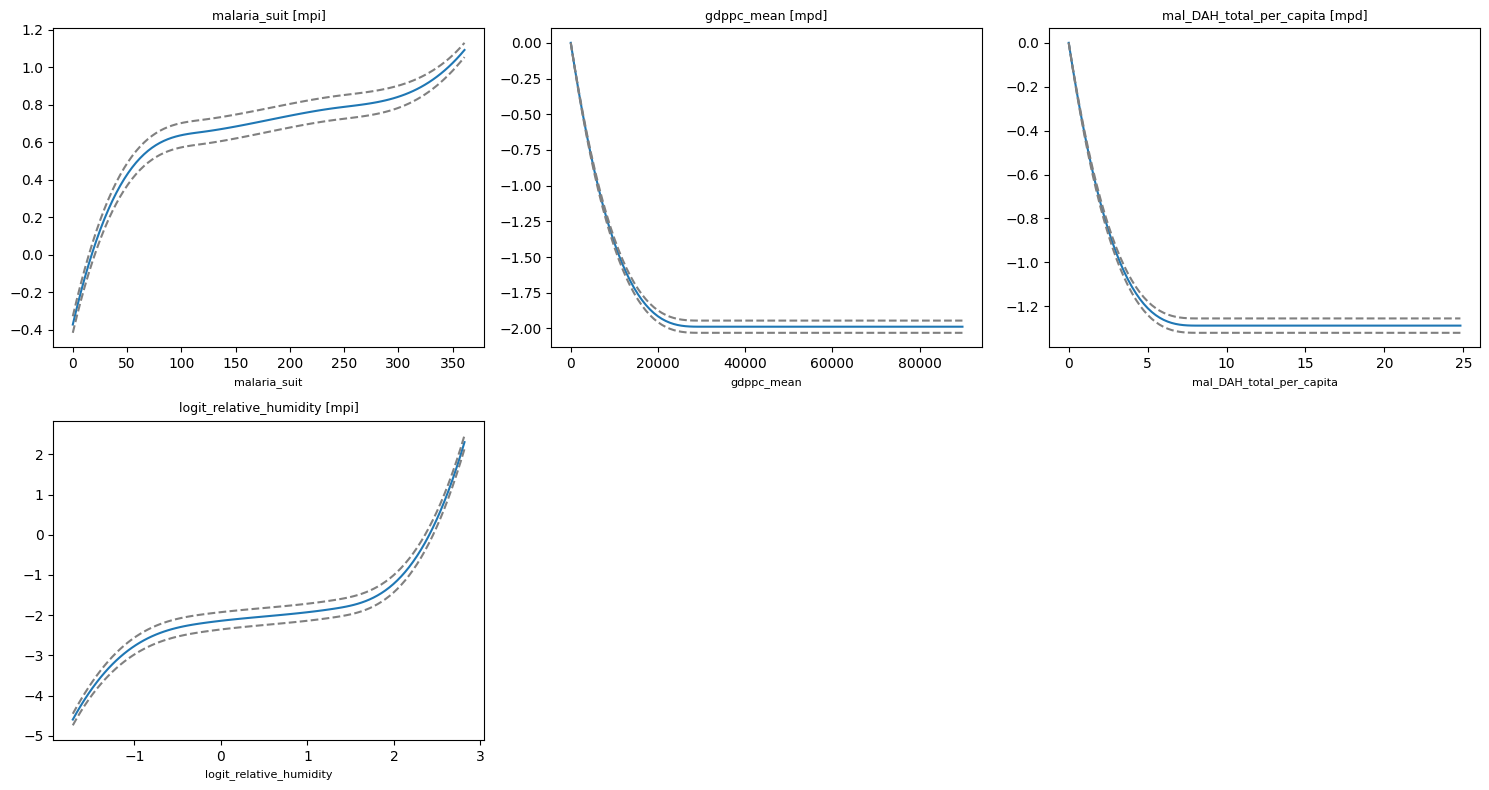

In [7]:
dim = "1D"
include_FE = True
FE_str = "with_FE" if include_FE else "without_FE"
name = f"{dim}_{FE_str}"
spec = dim_terms[dim] + base_spec
if include_FE:
    spec = spec + (FE_term,)
res = fits[(dim, FE_str)]

gam = res.models[0]          # IS fit = full-data fit
# gam = fit.fit_gam(df, pfpr_spec, fit.PFPR)   # single full-data (IS) fit, reused below
viz.plot_smooths(gam, spec, df);

In [10]:
spec

(Term(col='malaria_suit', form='mpi', k=6),
 Term(col='gdppc_mean', form='mpd', k=6),
 Term(col='mal_DAH_total_per_capita', form='mpd', k=6),
 Term(col='logit_relative_humidity', form='mpi', k=6),
 Term(col='A0_af', form='factor', k=None))

### Effect coefficients + p-values

`summary.term_pvalues` gives one p-value per term (the country factor's is a single *joint*
p-value). `summary.coefficient_table` pulls the interpretable parametric coefficients — the
linear effects (suitability, floods) and one row per country fixed effect (labelled by
`A0_location_id`) — with SEs, z, and an approximate p. Both are DataFrames you can save.

In [11]:
# dim = "1D"
# include_FE = True
# FE_str = "with_FE" if include_FE else "without_FE"
# name = f"{dim}_{FE_str}"
# spec = dim_terms[dim] + base_spec
# if include_FE:
#     spec = spec + (FE_term,)
# res = fits[(dim, FE_str)]

In [8]:
pval_df = summary.term_pvalues(gam, spec)             # per-term p-values (factor = joint)
coef_df = summary.coefficient_table(gam, spec, df)    # linear + per-country effects
pval_df

,term,form,edf,p_value
0,malaria_suit,mpi,4.457476e+00,1.110223e-16
1,gdppc_mean,mpd,1.275324e+00,1.110223e-16
2,mal_DAH_total_per_capita,mpd,1.542382e+00,1.110223e-16
3,logit_relative_humidity,mpi,4.369645e+00,1.110223e-16
4,A0_af,factor,6.772158e+01,1.110223e-16
5,intercept,intercept,6.744250e-20,1.110223e-16


In [13]:
# 1. locations whose 2023 row is complete on the columns you aggregate
rows = []
check_cols = ["population", "malaria_pfpr", "malaria_inc_rate", "malaria_mort_rate"]
ok_locs = df.loc[(df["year_id"] == 2023) & df[check_cols].notna().all(axis=1),
                 "location_id"].unique()

df_fit = df[df["location_id"].isin(ok_locs)].copy()

# 2. RE-ENCODE A0_af to dense 0..K-1 on the subset (pyGAM's factor needs gap-free codes;
#    a dropped country would otherwise leave a hole and under-fit the FE)
df_fit["A0_af"] = df_fit["A0_location_id"].astype("category").cat.codes.astype("int64")

# 3. refit on df_fit, and use df_fit everywhere downstream
res = fit.fit_predict(df_fit, spec, fit.PFPR, "IS")
gam = res.models[0]
coef_df = summary.coefficient_table(gam, spec, df_fit)   # df_fit here, so codes ↔ ids match

rows.append({"eval": 'subsetted_1D', **metrics.score_predictions(res.predictions)})
pd.DataFrame(rows).set_index("eval")[["n_obs", "r_sq", "rmse", "nat_r", "nat_rmse"]]

,n_obs,r_sq,rmse,nat_r,nat_rmse
eval,,,,,
subsetted_1D,126400,0.807575,1.079197,0.832461,0.114512


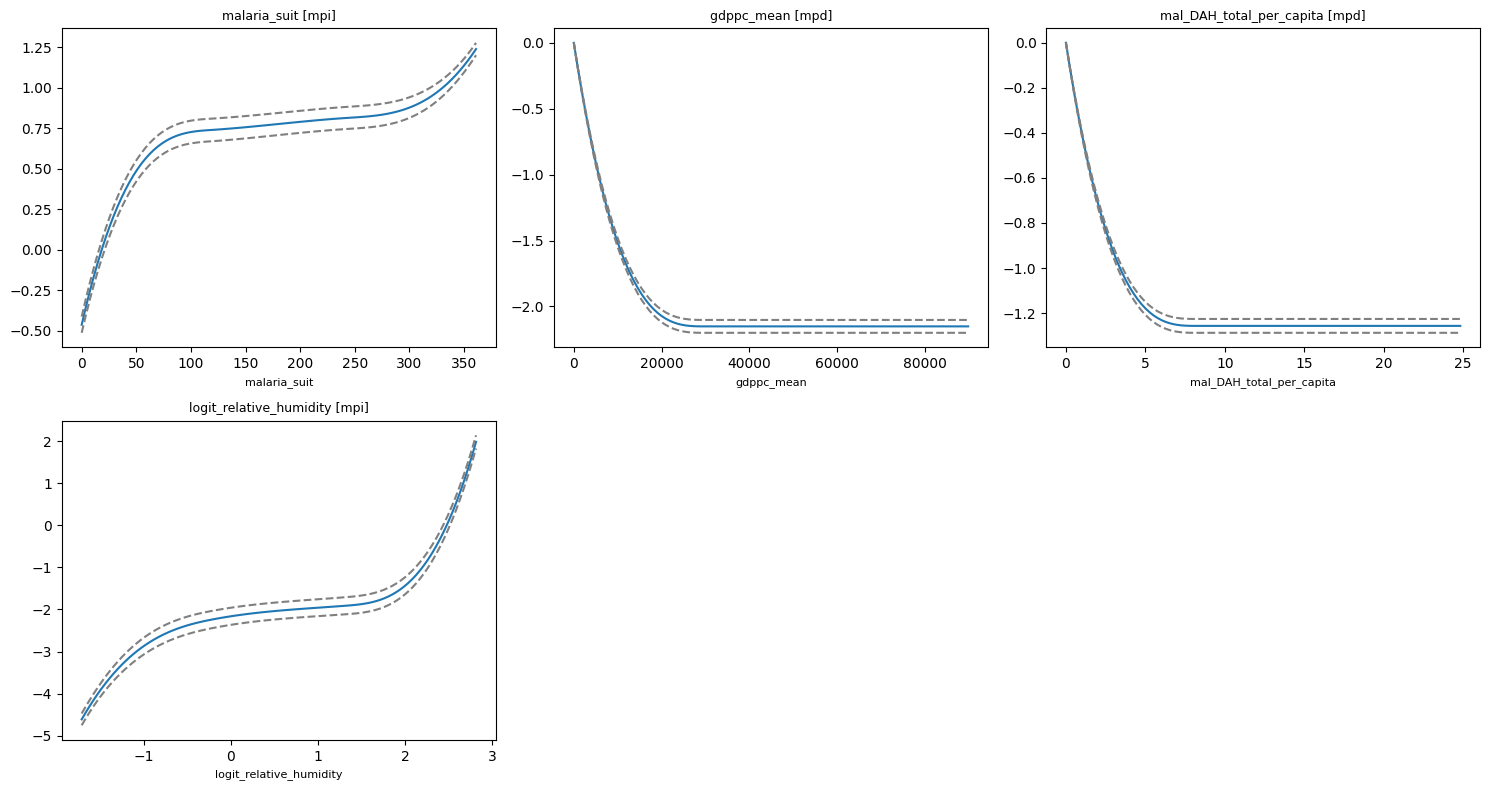

In [14]:
# gam = fit.fit_gam(df, pfpr_spec, fit.PFPR)   # single full-data (IS) fit, reused below
viz.plot_smooths(gam, spec, df);

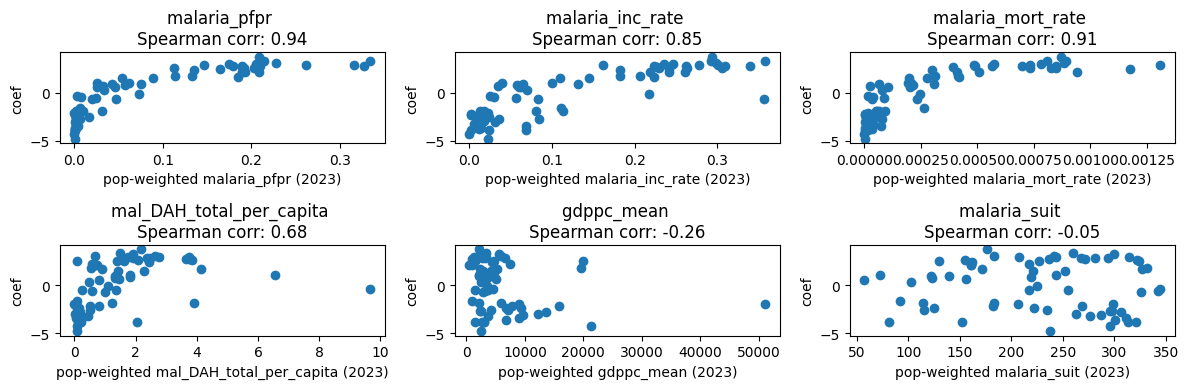

In [15]:
ref_year = 2023


check_cols = ["population", "malaria_pfpr", "malaria_inc_rate", "malaria_mort_rate"]
ok_locs = df.loc[(df["year_id"] == ref_year) & df[check_cols].notna().all(axis=1),
                 "location_id"].unique()

df_fit = df[df["location_id"].isin(ok_locs)].copy()

# 2. RE-ENCODE A0_af to dense 0..K-1 on the subset (pyGAM's factor needs gap-free codes;
#    a dropped country would otherwise leave a hole and under-fit the FE)
df_fit["A0_af"] = df_fit["A0_location_id"].astype("category").cat.codes.astype("int64")

# 3. refit on df_fit, and use df_fit everywhere downstream
res = fit.fit_predict(df_fit, spec, fit.PFPR, "IS")
gam = res.models[0]

ref_year_df = df_fit[df_fit["year_id"] == ref_year].copy()
pot_vars = ["malaria_pfpr", "malaria_inc_rate", "malaria_mort_rate", "mal_DAH_total_per_capita", "gdppc_mean", "malaria_suit"]
num = ref_year_df[pot_vars].mul(ref_year_df["population"], axis=0).groupby(ref_year_df["A0_location_id"]).sum()
totpop = ref_year_df.groupby("A0_location_id")["population"].sum()
agg_ref_year = num.div(totpop, axis=0).add_prefix("pop_wt_").add_suffix(f"_{ref_year}").reset_index()

coef_df = summary.coefficient_table(gam, spec, df_fit)   # df_fit here, so codes ↔ ids match
coef_df = coef_df.merge(agg_ref_year, left_on="level", right_on="A0_location_id", how="left") \
                 .drop(columns="A0_location_id")

# Create 3 scatter plots for pfpr, inc, and mort on x axis and y axis is the coef
import numpy as np
n_rows = int(np.floor(np.sqrt(len(pot_vars))))
n_cols = int(np.ceil(len(pot_vars) / n_rows))
fig, axs = plt.subplots(n_rows, n_cols, figsize=(12, 4))
axs = axs.flatten()
for c in pot_vars:
    axs[pot_vars.index(c)].scatter(coef_df[f"pop_wt_{c}_{ref_year}"], coef_df["coef"])
    axs[pot_vars.index(c)].set_xlabel(f"pop-weighted {c} ({ref_year})")
    axs[pot_vars.index(c)].set_ylabel("coef")
    tmp_spearman_corr = coef_df[[f"pop_wt_{c}_{ref_year}", "coef"]].corr(method="spearman").iloc[0, 1]
    tmp_title = f"{c} \nSpearman corr: {tmp_spearman_corr:.2f}"
    axs[pot_vars.index(c)].set_title(tmp_title)
fig.tight_layout()


In [16]:
# --- true lagged admin-0 pop-weighted pfpr covariate (Version 1), X=10 ---
X = 10
log_flag = True

df_lag  = data.add_a0_lag(df, var="malaria_pfpr", lag_years=X,
                          transform="logit" if log_flag else None)   # logit (not log) — pfpr is a small rate

lag_col = f"logit_lag{X}_a0_pfpr" if log_flag else f"lag{X}_a0_pfpr"

# fair A/B: restrict EVERY model to rows where the lag exists (years >= 2000+X), so
# lag-vs-nolag is apples-to-apples on the same rows
df_cmp = df_lag.dropna(subset=[lag_col]).copy()
df_cmp["A0_af"] = df_cmp["A0_location_id"].astype("category").cat.codes.astype("int64")  # keep codes dense

base  = (specs.Term("malaria_suit", "mpi", 6), specs.Term("gdppc_mean", "mpd", 6),
         specs.Term("mal_DAH_total_per_capita", "mpd", 6), specs.Term("logit_relative_humidity", "mpi", 6))
lag_t = specs.Term(lag_col, "mpi", 6)
FE_t  = specs.Term("A0_af", "factor")

og_rows, og_fits = [], {}
for use_lag in [False, True]:
    for include_FE in [False, True]:
        spec = base + ((lag_t,) if use_lag else ()) + ((FE_t,) if include_FE else ())
        res  = fit.fit_predict(df_cmp, spec, fit.PFPR, "IS")
        name = f"{'lag' if use_lag else 'nolag'}_{'FE' if include_FE else 'noFE'}"
        og_fits[name] = res
        og_rows.append({"model": name, **metrics.score_predictions(res.predictions)})
pd.DataFrame(og_rows).set_index("model")[["n_obs", "r_sq", "rmse", "nat_r"]]


,n_obs,r_sq,rmse,nat_r
model,,,,
nolag_noFE,86725,0.146589,2.560442,0.344419
nolag_FE,86725,0.840932,1.105421,0.828722
lag_noFE,86725,0.768844,1.332565,0.775715
lag_FE,86725,0.841130,1.104733,0.831094


In [ ]:
use_lag = True
include_FE = False
base  = (specs.Term("malaria_suit", "mpi", 6), specs.Term("gdppc_mean", "mpd", 6),
         specs.Term("mal_DAH_total_per_capita", "mpd", 6), specs.Term("logit_relative_humidity", "mpi", 6))
FE_t  = specs.Term("A0_af", "factor")
X_range = range(1, 16)

# 1. add every lag's columns onto ONE frame (distinct X -> distinct col names, no collision)
df_all = df.copy()
for X in X_range:
    df_all = data.add_a0_lag(df_all, var="malaria_mort_rate", lag_years=X, transform="log")
    df_all = data.add_a0_lag(df_all, var="malaria_inc_rate", lag_years=X, transform="log")

# 2. common rows = complete on ALL lags == the rows the most restrictive lag (X=15) keeps
lag_cols = [f"lag{X}_a0_mort_rate" for X in X_range]          # raw cols; log cols share the NaN pattern
common = df_all.dropna(subset=lag_cols).copy()
fit_years = range(2019, 2024)
common = common[common["year_id"].isin(fit_years)].copy()
print(f"common row set: {len(common):,} rows, years {int(common.year_id.min())}-{int(common.year_id.max())}")






rows, fits = [], {}

spec = base + (FE_t,)
res  = fit.fit_predict(common, spec, fit.PFPR, "IS")
name = f"FE_model"
combo = 'None'
X = 0
log_flag = False
fits[name] = res
rows.append({"model": name, "X": X, "combo": combo, "log": log_flag,
                         **metrics.score_predictions(res.predictions)})   # <- X/combo/log recorded

for X in X_range:
    for log_flag in [True, False]:
        tag = "log" if log_flag else "raw"
        inc_t  = specs.Term(f"log_lag{X}_a0_inc_rate"  if log_flag else f"lag{X}_a0_inc_rate",  "mpi", 6)
        mort_t = specs.Term(f"log_lag{X}_a0_mort_rate" if log_flag else f"lag{X}_a0_mort_rate", "mpi", 6)
        for combo, terms in [("inc", (inc_t,)), ("mort", (mort_t,)), ("inc+mort", (inc_t, mort_t))]:
            res  = fit.fit_predict(common, base + terms, fit.PFPR, "IS")
            name = f"X{X}_{combo}_{tag}"
            fits[name] = res
            rows.append({"model": name, "X": X, "combo": combo, "log": log_flag,
                         **metrics.score_predictions(res.predictions)})   # <- X/combo/log recorded
pd.DataFrame(rows).set_index("model")[["n_obs", "r_sq", "rmse", "nat_r"]]

common row set: 27,824 rows, years 2019-2023


,n_obs,r_sq,rmse,nat_r
model,,,,
X1_inc_log,27824,0.733304,1.327256,0.810485
X1_mort_log,27824,0.757994,1.264325,0.817431
X1_inc+mort_log,27824,0.765452,1.244691,0.826978
X1_inc_raw,27824,0.733342,1.327159,0.808969
X1_mort_raw,27824,0.744379,1.299404,0.835009
...,...,...,...,...
X15_mort_log,27824,0.730937,1.333131,0.805414
X15_inc+mort_log,27824,0.738981,1.313052,0.810779
X15_inc_raw,27824,0.717223,1.366685,0.777770


KeyError: 'model'

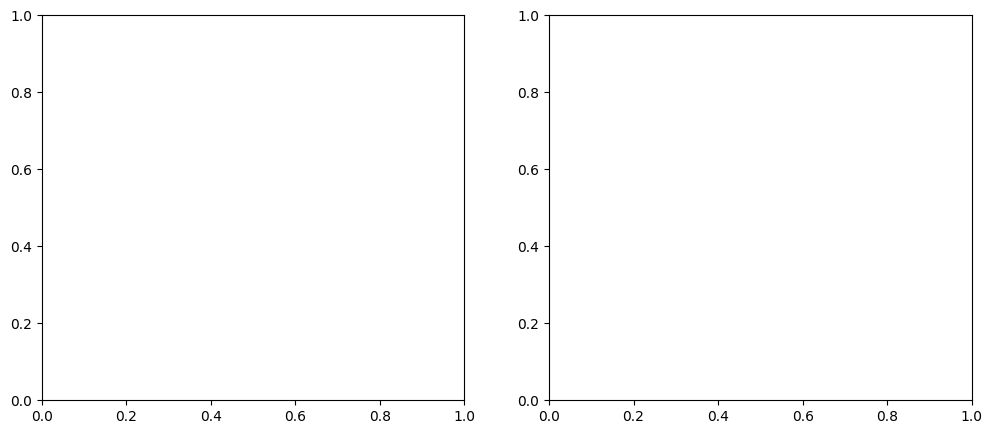

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)
FE_row = next(r for r in rows if r["model"] == "FE_model")

colors = {"inc": "tab:blue", "mort": "tab:orange", "inc+mort": "tab:green"}
styles = {True: "-", False: "--"}          # log solid, raw dashed

for ax, col in zip(axes, ["r_sq", "nat_r"]):
    ylab = "nat_r^2" if col == "nat_r" else col
    for combo in colors:
        for log_flag in (True, False):
            sel = sorted((r for r in rows if r["combo"] == combo and r["log"] == log_flag),
                         key=lambda r: r["X"])
            xs = [r["X"] for r in sel]
            ys = [r[col]**2 if col == "nat_r" else r[col] for r in sel]
            ax.plot(xs, ys, color=colors[combo], linestyle=styles[log_flag],
                    label=f"{combo} ({'log' if log_flag else 'raw'})")
    fe = FE_row[col]**2 if col == "nat_r" else FE_row[col]
    ax.axhline(fe, color="gray", linestyle=":", label="nolag_FE")
    ax.set_xlabel("lag (years)"); ax.set_ylabel(ylab); ax.set_title(ylab); ax.set_ylim(0.5, 1)
axes[1].legend(fontsize=8, loc="best")     # one legend covers both panels
fig.suptitle("lagged admin-0 inc/mort_rate covariates vs PfPR (IS, common rows)")
fig.tight_layout()


In [17]:
1+1

2

In [14]:
import pandas as pd

X_range = range(1, 16)

# --- build lag columns once ---
df = data.load_modeling_data(row_filter="modeled")
df_all = df.copy()
# for X in X_range:
#     df_all = data.add_a0_lag(df_all, var="malaria_mort_rate", lag_years=X, transform="log")
#     df_all = data.add_a0_lag(df_all, var="malaria_inc_rate",  lag_years=X, transform="log")
for X in X_range:
    df_all = data.add_a0_lag(df_all, var="malaria_pfpr", lag_years=X, transform="logit")


base = (specs.Term("malaria_suit", "mpi", 6), specs.Term("gdppc_mean", "mpd", 6),
        specs.Term("mal_DAH_total_per_capita", "mpd", 6), specs.Term("logit_relative_humidity", "mpi", 6))
FE_t = specs.Term("A0_af", "factor")
FACTOR_LAM = 1e-3
base_cols = ["A0_location_id", "year_id", "malaria_suit", "gdppc_mean",
             "mal_DAH_total_per_capita", "logit_relative_humidity"]

# ── window dict = single source of truth ────────────────────────────────
window_dict = {
    "h1_horizon1": {"train": {"start": 2000, "end": 2010}, "test": {"start": 2011, "end": 2011}},
    "h1_horizon3": {"train": {"start": 2000, "end": 2010}, "test": {"start": 2013, "end": 2015}},
    "h1_horizon6": {"train": {"start": 2000, "end": 2010}, "test": {"start": 2016, "end": 2018}},
    "h1_horizon9": {"train": {"start": 2000, "end": 2010}, "test": {"start": 2019, "end": 2021}},
    "matched_avail": {"train": {"start": 2015, "end": 2019}, "test": {"start": 2020, "end": 2023}},
    "late_train":  {"train": {"start": 2010, "end": 2019}, "test": {"start": 2020, "end": 2023}},
    "early_train": {"train": {"start": 2000, "end": 2015}, "test": {"start": 2016, "end": 2019}},
    "pre-COVID":          {"train": {"start": 2000, "end": 2016}, "test": {"start": 2017, "end": 2019}},
    "pre-and-post-COVID": {"train": {"start": 2000, "end": 2017}, "test": {"start": 2019, "end": 2021}},
    "COVID+":             {"train": {"start": 2000, "end": 2019}, "test": {"start": 2020, "end": 2023}},
}

windows = {
    name: fit.Temporal(w["train"]["start"], w["train"]["end"],
                       w["test"]["start"],  w["test"]["end"], name=name)
    for name, w in window_dict.items()
}

# horizon = gap between train end and test start (0 if adjacent). Used for Exp 1 slope reads.
def window_meta(name):
    w = window_dict[name]
    return {
        "train_start": w["train"]["start"], "train_end": w["train"]["end"],
        "test_start":  w["test"]["start"],  "test_end":  w["test"]["end"],
        "horizon": w["test"]["start"] - w["train"]["end"],
    }

# experiment groupings
horizon_windows  = [windows[k] for k in ["h1_horizon1", "h1_horizon3", "h1_horizon6", "h1_horizon9"]]
confound_windows = [windows["matched_avail"]]
backfill_windows = [windows["late_train"], windows["early_train"]]
legacy_windows   = [windows[k] for k in ["pre-COVID", "pre-and-post-COVID", "COVID+"]]

def fit_one(frame, spec, outcome, window, factor_lam=None):
    sub = frame.copy()
    sub["A0_af"] = sub["A0_location_id"].astype("category").cat.codes.astype("int64")
    kwargs = {"factor_lam": factor_lam} if factor_lam is not None else {}
    res = fit.fit_predict(sub, spec, outcome, window, **kwargs)
    scores = metrics.score_predictions(res.predictions)
    n_train = int(((sub.year_id >= window.train_lo) & (sub.year_id <= window.train_hi)).sum())
    return res, scores, n_train

# def lag_terms(X, log_flag):
#     inc_col  = f"log_lag{X}_a0_inc_rate"  if log_flag else f"lag{X}_a0_inc_rate"
#     mort_col = f"log_lag{X}_a0_mort_rate" if log_flag else f"lag{X}_a0_mort_rate"
#     inc_t, mort_t = specs.Term(inc_col, "mpi", 6), specs.Term(mort_col, "mpi", 6)
#     return [("inc", (inc_t,), [inc_col]),
#             ("mort", (mort_t,), [mort_col]),
#             ("inc+mort", (inc_t, mort_t), [inc_col, mort_col])]
def lag_terms(X, log_flag):
    pfpr_col = f"logit_lag{X}_a0_pfpr" if log_flag else f"lag{X}_a0_pfpr"
    pfpr_t = specs.Term(pfpr_col, "mpi", 6)
    return [("pfpr", (pfpr_t,), [pfpr_col])]

/ihme/homes/bcreiner/miniconda/envs/idd-forecast-mbp/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [15]:
# ══ Option A: fixed common rows across all lags (cross-lag comparable) ═══
def run_sweep_A(win_list, X_range=X_range):
    # all_lag_cols = [f"lag{X}_a0_{v}" for X in X_range for v in ("mort_rate", "inc_rate")]
    all_lag_cols = [f"lag{X}_a0_pfpr" for X in X_range]
    common = df_all.dropna(subset=base_cols + all_lag_cols).copy()
    print(f"Option A common rows: {len(common):,} (years {int(common.year_id.min())}-{int(common.year_id.max())})")

    rows, fits = [], {}
    for ev in win_list:
        res, sc, nt = fit_one(common, base + (FE_t,), fit.PFPR, ev, FACTOR_LAM)
        fits[f"FE_model_{ev.name}"] = res
        rows.append({"model": f"FE_model_{ev.name}", "window": ev.name, "X": 0,
                     "combo": "None", "log": False, "n_train": nt, **window_meta(ev.name), **sc})

    for X in X_range:
        print(f"  A: X={X}...")
        for log_flag in [True, False]:
            tag = "logit" if log_flag else "raw"
            for combo, terms, _ in lag_terms(X, log_flag):
                for ev in win_list:
                    res, sc, nt = fit_one(common, base + terms, fit.PFPR, ev)
                    name = f"X{X}_{combo}_{tag}_{ev.name}"
                    fits[name] = res
                    rows.append({"model": name, "window": ev.name, "X": X, "combo": combo,
                                 "log": log_flag, "n_train": nt, **window_meta(ev.name), **sc})

    res_df = pd.DataFrame(rows)
    base_nt = res_df[res_df["X"] == 0].set_index("window")["n_train"]
    res_df["n_train_vs_baseline"] = res_df.apply(lambda r: r["n_train"] / base_nt[r["window"]], axis=1)
    return res_df, fits

# ══ Option B: per-lag matched FE baseline, max data per lag ══════════════
def run_sweep_B(win_list, X_range=X_range):
    rows, fits = [], {}
    for X in X_range:
        print(f"  B: X={X}...")
        for log_flag in [True, False]:
            tag = "logit" if log_flag else "raw"
            terms_list = lag_terms(X, log_flag)
            # this_lag_cols = [f"log_lag{X}_a0_inc_rate"  if log_flag else f"lag{X}_a0_inc_rate",
            #                  f"log_lag{X}_a0_mort_rate" if log_flag else f"lag{X}_a0_mort_rate"]
            this_lag_cols = [f"logit_lag{X}_a0_pfpr" if log_flag else f"lag{X}_a0_pfpr"]
            frame_X = df_all.dropna(subset=base_cols + this_lag_cols).copy()

            for ev in win_list:
                res_fe, sc_fe, nt_fe = fit_one(frame_X, base + (FE_t,), fit.PFPR, ev, FACTOR_LAM)
                fits[f"FE_X{X}_{tag}_{ev.name}"] = res_fe
                rows.append({"model": f"FE_X{X}_{tag}_{ev.name}", "window": ev.name, "X": X,
                             "combo": "FE_matched", "log": log_flag, "n_train": nt_fe,
                             **window_meta(ev.name), **sc_fe})
                for combo, term_tuple, _ in terms_list:
                    res, sc, nt = fit_one(frame_X, base + term_tuple, fit.PFPR, ev)
                    name = f"X{X}_{combo}_{tag}_{ev.name}"
                    fits[name] = res
                    rows.append({"model": name, "window": ev.name, "X": X, "combo": combo,
                                 "log": log_flag, "n_train": nt, **window_meta(ev.name), **sc})

    res_df = pd.DataFrame(rows)
    fe_nt = (res_df[res_df["combo"] == "FE_matched"].set_index(["window", "X", "log"])["n_train"])
    def _ratio(r):
        if r["combo"] == "FE_matched":
            return 1.0
        return r["n_train"] / fe_nt.loc[(r["window"], r["X"], r["log"])]
    res_df["n_train_vs_baseline"] = res_df.apply(_ratio, axis=1)
    return res_df, fits

In [16]:
# ── run per experiment ──────────────────────────────────────────────────
results_A, fits_A = run_sweep_A(legacy_windows + backfill_windows)
results_B, fits_B = run_sweep_B(legacy_windows + backfill_windows)
# Exp 1 (horizon gate) only needs short lags — run separately, cheaper:
results_horizon, _ = run_sweep_A(horizon_windows, X_range=range(1, 4))

Option A common rows: 52,404 (years 2015-2023)
  A: X=1...
  A: X=2...
  A: X=3...
  A: X=4...
  A: X=5...
  A: X=6...
  A: X=7...
  A: X=8...
  A: X=9...
  A: X=10...
  A: X=11...
  A: X=12...
  A: X=13...
  A: X=14...
  A: X=15...
  B: X=1...
  B: X=2...
  B: X=3...
  B: X=4...
  B: X=5...
  B: X=6...
  B: X=7...
  B: X=8...
  B: X=9...
  B: X=10...
  B: X=11...
  B: X=12...
  B: X=13...
  B: X=14...
  B: X=15...
Option A common rows: 140,082 (years 2003-2023)
  A: X=1...
  A: X=2...
  A: X=3...


In [17]:
import math
import matplotlib.pyplot as plt

def plot_lag_sweep(results, metric="nat_r", thin_thresh=0.5, window_order=None):
    wins = list(dict.fromkeys(results["window"])) if window_order is None \
           else [w for w in window_order if w in set(results["window"])]
    combos = ["pfpr"]                                       # <- only pfpr now
    colors = {"pfpr": "tab:red"}                            # <- single color
    styles = {True: "-", False: "--"}                      # logit solid, raw dashed
    thin_col = "n_train_vs_full" if "n_train_vs_full" in results.columns else "n_train_vs_baseline"

    n = len(wins)
    ncols = min(3, n); nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 4.2*nrows),
                             sharey=True, squeeze=False)
    axes = axes.flatten()

    for ax, window in zip(axes, wins):
        w = results[results["window"] == window]

        fe = w[w["combo"] == "FE_matched"]
        if not fe.empty:                                   # Option B: FE refit per lag
            f = fe.drop_duplicates("X").sort_values("X")
            ax.plot(f["X"], f[metric], color="gray", ls="-", marker="x", lw=1.5,
                    label="base+FE (matched)")
        else:                                              # Option A: single ceiling
            b = w[w["X"] == 0]
            if not b.empty:
                ax.axhline(b[metric].iloc[0], color="gray", ls=":", lw=1.5,
                           label="base+FE (no lag)")

        lag = w[(w["X"] > 0) & (w["combo"].isin(combos))]
        for combo in combos:
            for lf in (True, False):
                s = lag[(lag["combo"] == combo) & (lag["log"] == lf)].sort_values("X")
                if s.empty:
                    continue
                ax.plot(s["X"], s[metric], color=colors[combo], ls=styles[lf],
                        marker="o", ms=4, label=f"{combo} ({'logit' if lf else 'raw'})")  # <- logit label
                thin = s[s[thin_col] < thin_thresh]
                if not thin.empty:
                    ax.scatter(thin["X"], thin[metric], facecolors="none",
                               edgecolors="red", s=140, lw=1.5, zorder=5)

        ax.set_title(window, fontsize=9); ax.set_xlabel("lag (years)")
        ax.set_ylabel(metric); ax.grid(alpha=0.2)

    for ax in axes[n:]:            # hide unused grid cells (e.g. 5 windows in a 3×2 grid)
        ax.set_visible(False)
    axes[0].legend(fontsize=7, loc="best")
    fig.suptitle(f"{metric} by lag vs base+FE   (red rings: {thin_col} < {int(thin_thresh*100)}%)")
    fig.tight_layout()
    return fig

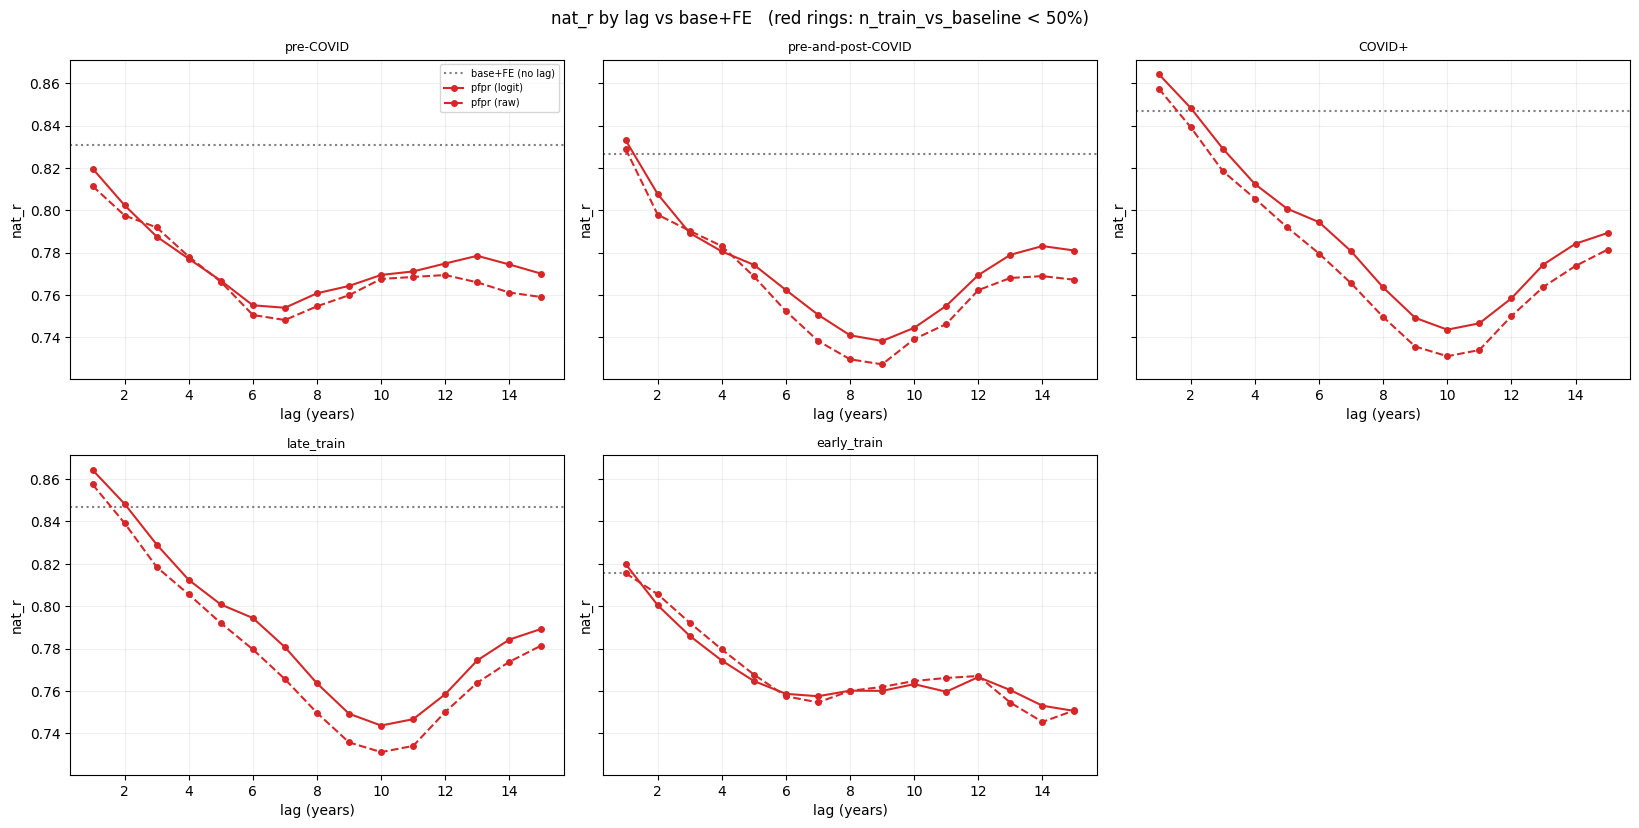

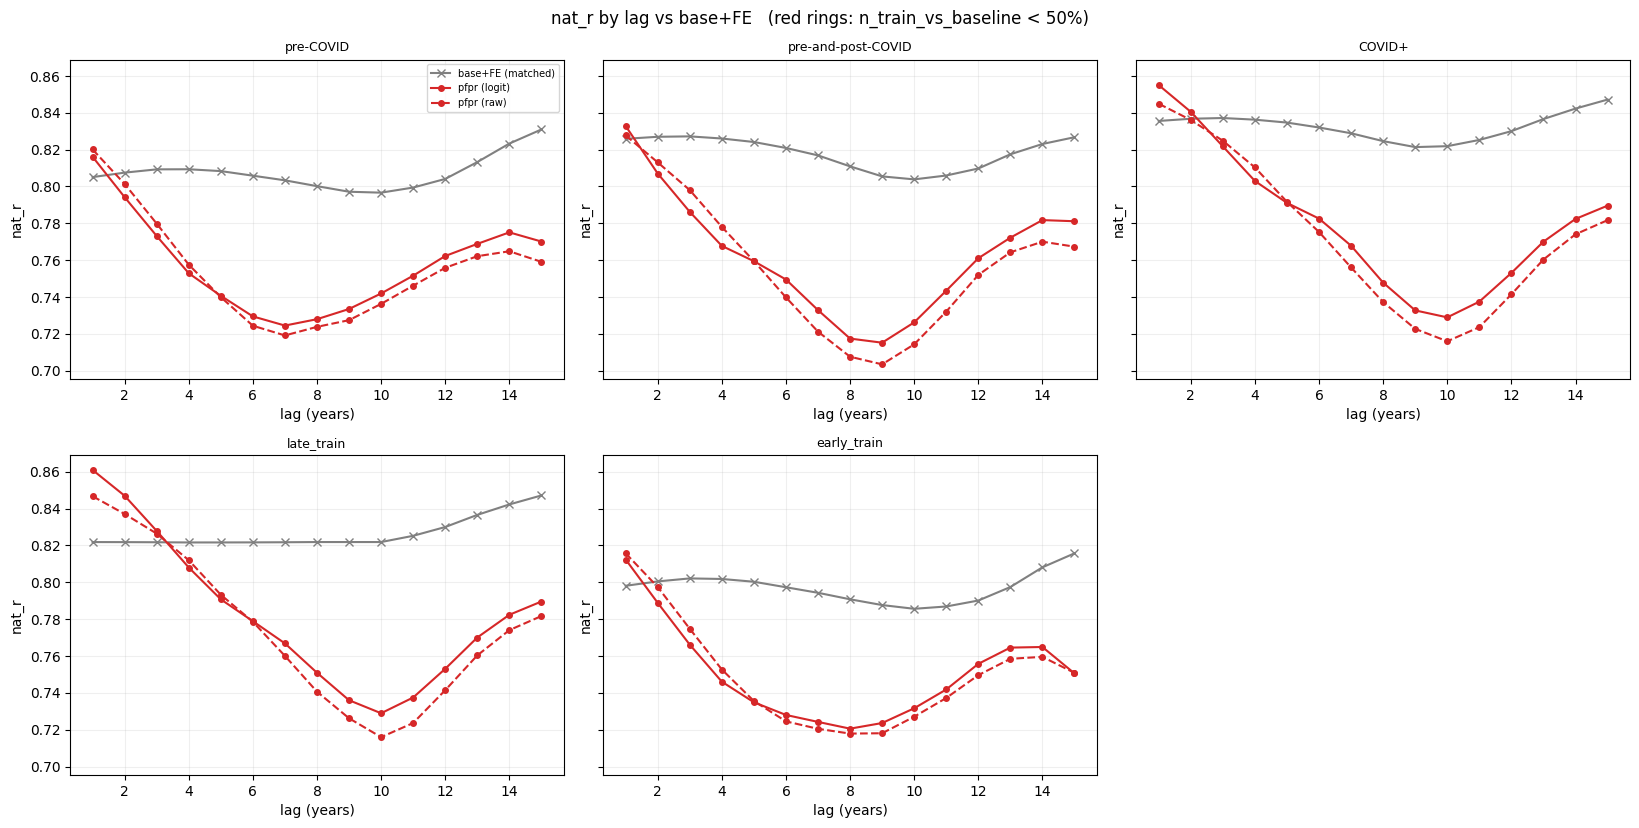

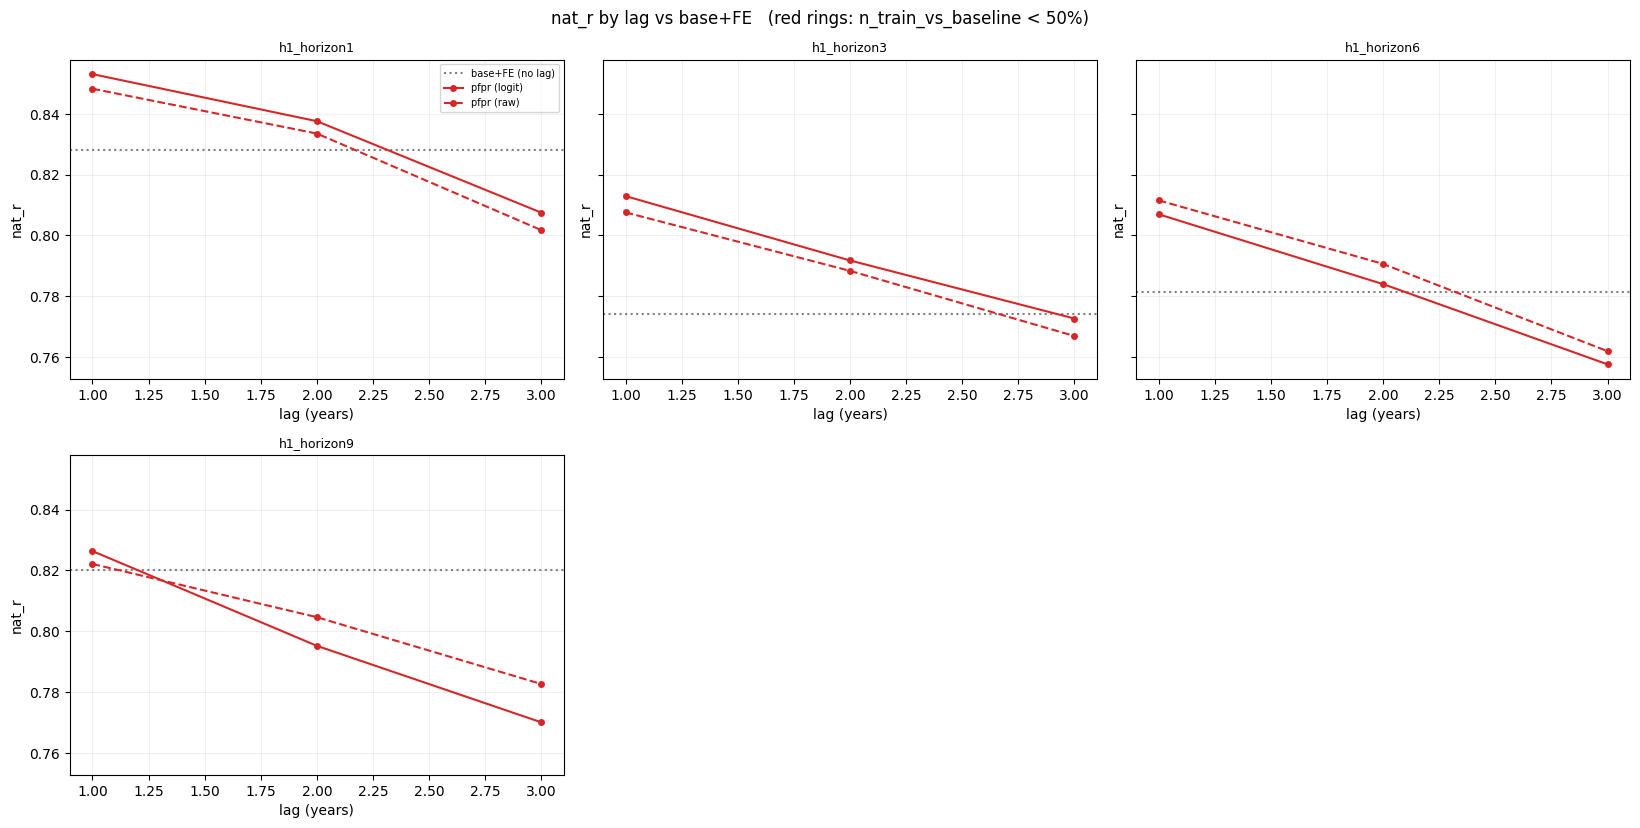

In [18]:
plot_lag_sweep(results_A, metric="nat_r")        # cross-lag comparable (flat ceiling), 5 windows
plot_lag_sweep(results_B, metric="nat_r")        # per-lag matched FE (varying gray line), 5 windows
plot_lag_sweep(results_horizon, metric="nat_r")  # horizon windows, lags 1-3
plt.show()


In [26]:
import math
import matplotlib.pyplot as plt

def plot_lag_sweep(results, metric="nat_r", thin_thresh=0.5, window_order=None):
    wins = list(dict.fromkeys(results["window"])) if window_order is None \
           else [w for w in window_order if w in set(results["window"])]
    combos = ["inc", "mort", "inc+mort"]
    colors = {"inc": "tab:blue", "mort": "tab:orange", "inc+mort": "tab:green"}
    styles = {True: "-", False: "--"}                      # log solid, raw dashed
    thin_col = "n_train_vs_full" if "n_train_vs_full" in results.columns else "n_train_vs_baseline"

    n = len(wins)
    ncols = min(3, n); nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 4.2*nrows),
                             sharey=True, squeeze=False)
    axes = axes.flatten()

    for ax, window in zip(axes, wins):
        w = results[results["window"] == window]

        fe = w[w["combo"] == "FE_matched"]
        if not fe.empty:                                   # Option B: FE refit per lag
            f = fe.drop_duplicates("X").sort_values("X")
            ax.plot(f["X"], f[metric], color="gray", ls="-", marker="x", lw=1.5,
                    label="base+FE (matched)")
        else:                                              # Option A: single ceiling
            b = w[w["X"] == 0]
            if not b.empty:
                ax.axhline(b[metric].iloc[0], color="gray", ls=":", lw=1.5,
                           label="base+FE (no lag)")

        lag = w[(w["X"] > 0) & (w["combo"].isin(combos))]
        for combo in combos:
            for lf in (True, False):
                s = lag[(lag["combo"] == combo) & (lag["log"] == lf)].sort_values("X")
                if s.empty:
                    continue
                ax.plot(s["X"], s[metric], color=colors[combo], ls=styles[lf],
                        marker="o", ms=4, label=f"{combo} ({'log' if lf else 'raw'})")
                thin = s[s[thin_col] < thin_thresh]
                if not thin.empty:
                    ax.scatter(thin["X"], thin[metric], facecolors="none",
                               edgecolors="red", s=140, lw=1.5, zorder=5)

        ax.set_title(window, fontsize=9); ax.set_xlabel("lag (years)")
        ax.set_ylabel(metric); ax.grid(alpha=0.2)

    for ax in axes[n:]:            # hide unused grid cells (e.g. 5 windows in a 3×2 grid)
        ax.set_visible(False)
    axes[0].legend(fontsize=7, loc="best")
    fig.suptitle(f"{metric} by lag vs base+FE   (red rings: {thin_col} < {int(thin_thresh*100)}%)")
    fig.tight_layout()
    return fig


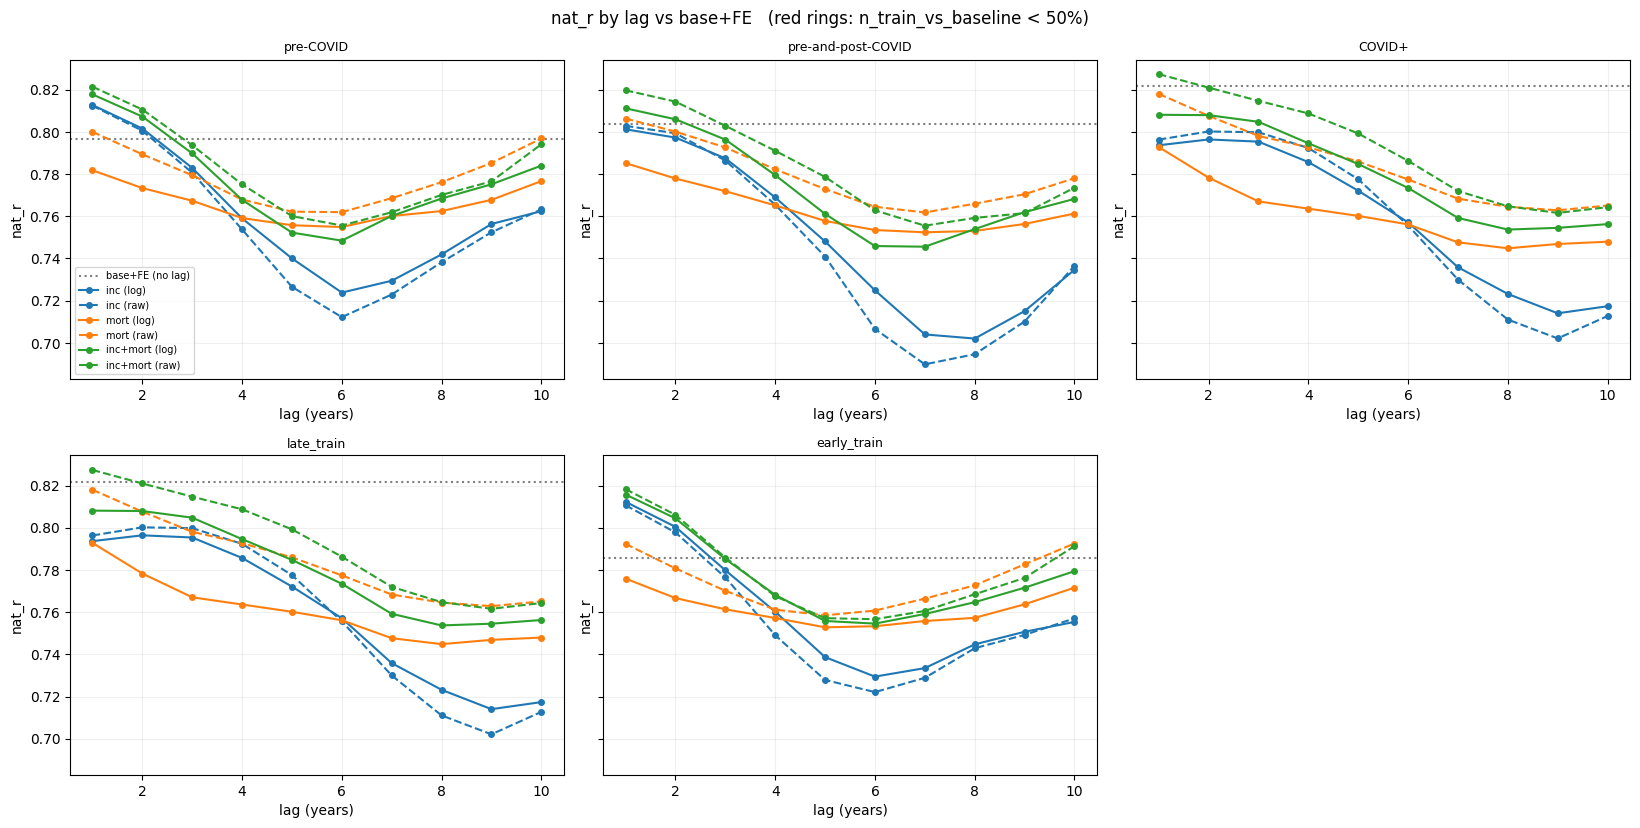

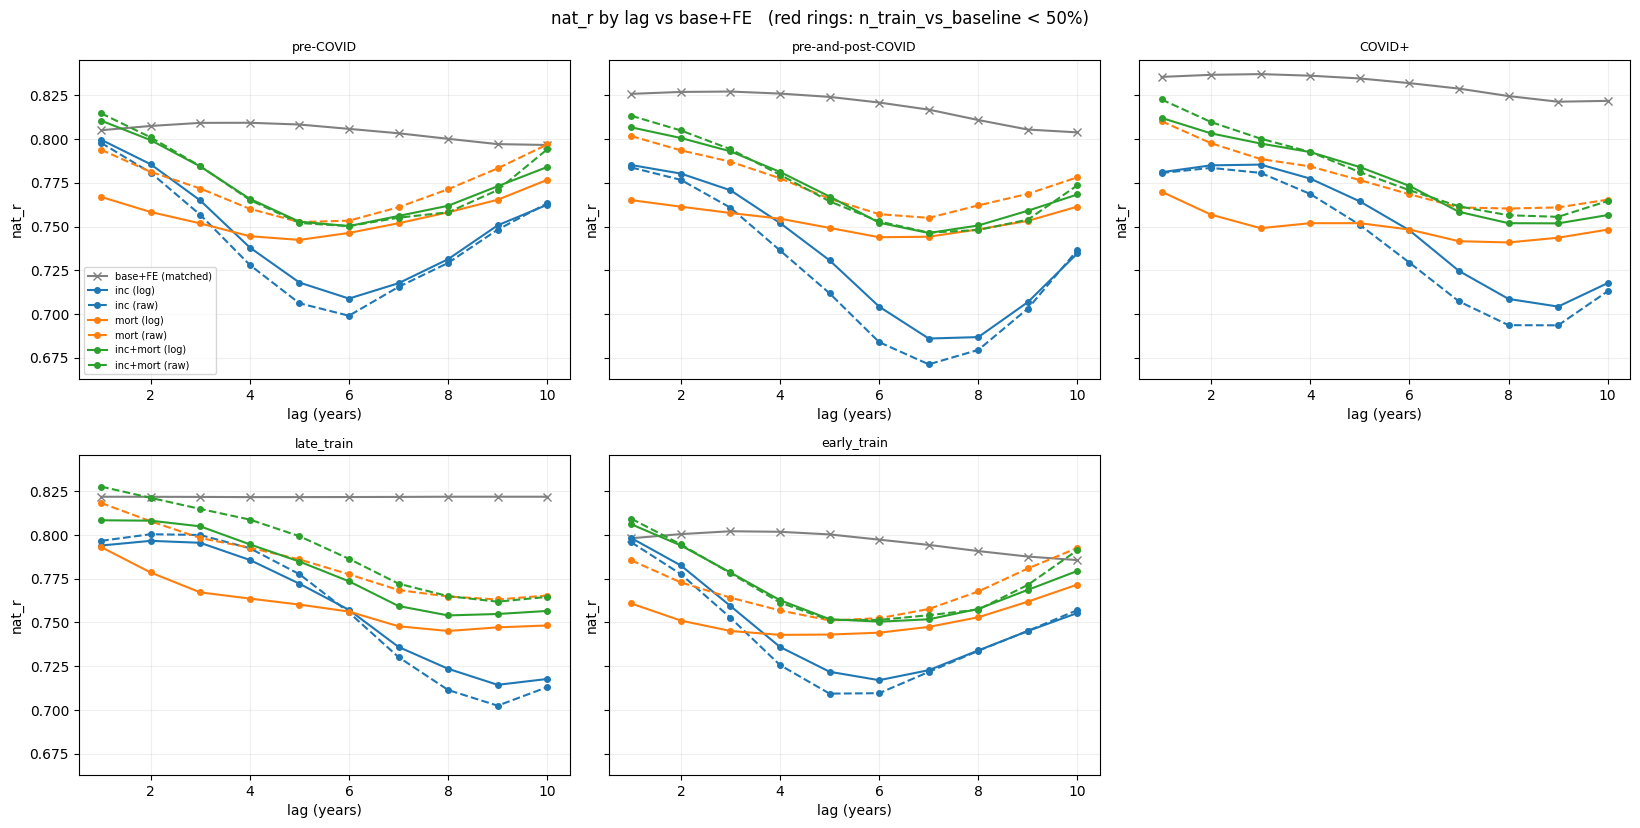

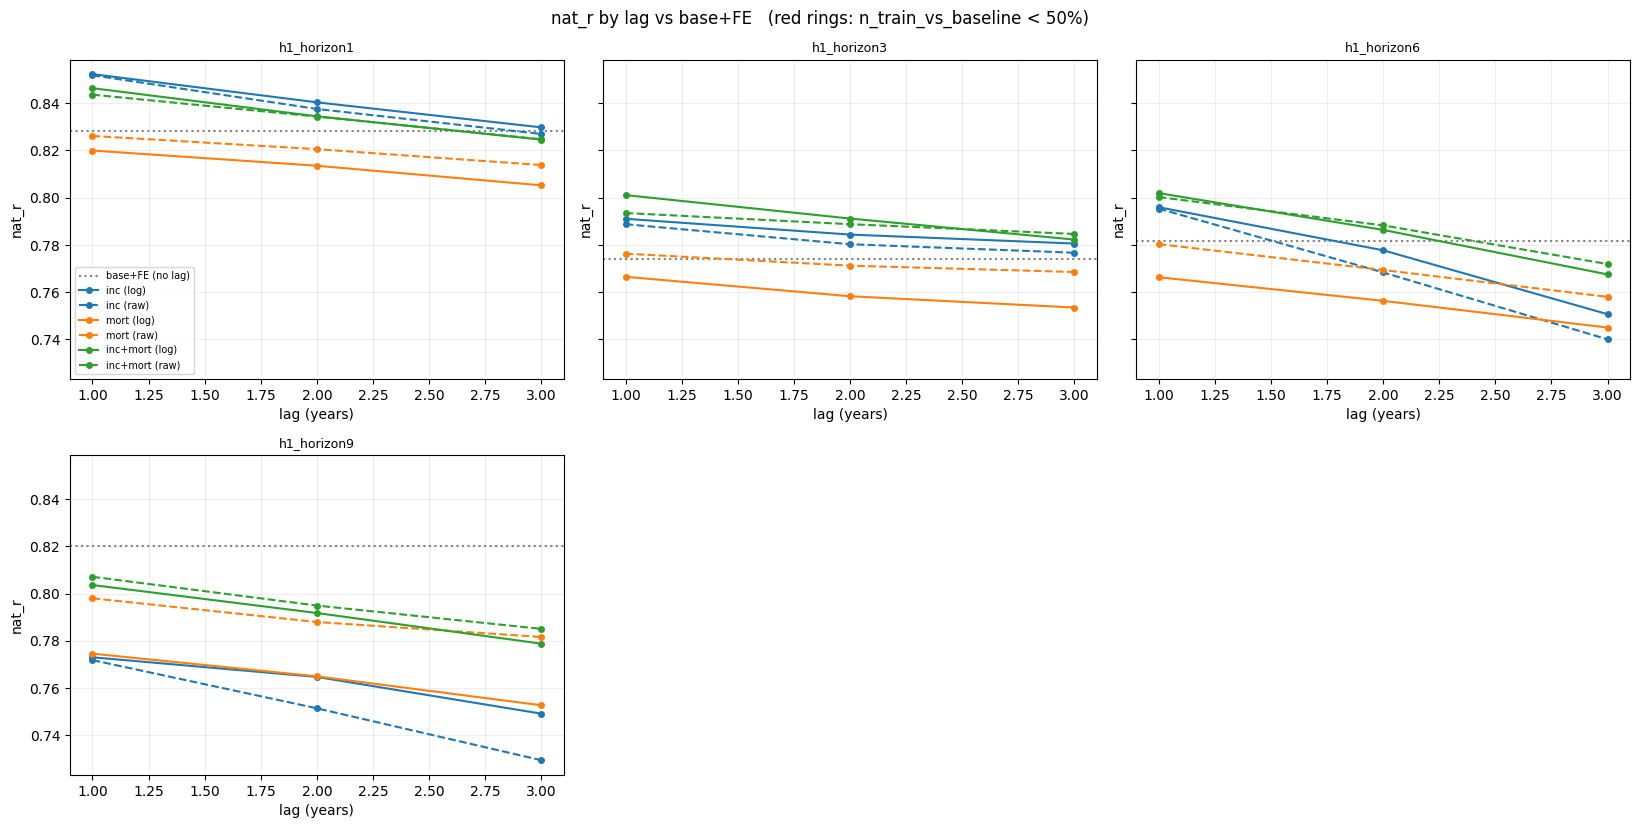

In [27]:
plot_lag_sweep(results_A, metric="nat_r")        # cross-lag comparable (flat ceiling), 5 windows
plot_lag_sweep(results_B, metric="nat_r")        # per-lag matched FE (varying gray line), 5 windows
plot_lag_sweep(results_horizon, metric="nat_r")  # horizon windows, lags 1-3
plt.show()


In [70]:
rows_B, fits_B = [], {}
for X in X_range:
    print(f"Fitting lagged covariates for X={X}...")
    for log_flag in [True, False]:
        tag = "log" if log_flag else "raw"
        terms_list = lag_terms(X, log_flag)
        # row set for THIS lag = complete on this lag's inc+mort cols (the widest need among its combos)
        this_lag_cols = [f"log_lag{X}_a0_inc_rate"  if log_flag else f"lag{X}_a0_inc_rate",
                         f"log_lag{X}_a0_mort_rate" if log_flag else f"lag{X}_a0_mort_rate"]
        frame_X = df_all.dropna(subset=base_cols + this_lag_cols).copy()

        for ev in windows:
            # matched FE baseline on the SAME rows as this lag/transform
            res_fe, sc_fe, nt_fe = fit_one(frame_X, base + (FE_t,), fit.PFPR, ev, FACTOR_LAM)
            fits_B[f"FE_X{X}_{tag}_{ev.name}"] = res_fe
            rows_B.append({"model": f"FE_X{X}_{tag}_{ev.name}", "window": ev.name, "X": X,
                           "combo": "FE_matched", "log": log_flag, "n_train": nt_fe, **sc_fe})

            for combo, term_tuple, _ in terms_list:
                res, sc, n_train = fit_one(frame_X, base + term_tuple, fit.PFPR, ev)
                name = f"X{X}_{combo}_{tag}_{ev.name}"
                fits_B[name] = res
                rows_B.append({"model": name, "window": ev.name, "X": X, "combo": combo,
                               "log": log_flag, "n_train": n_train, **sc})

results_B = pd.DataFrame(rows_B)
# in B the "baseline" is the matched FE per (X, log, window); flag lag cells vs their own matched FE
fe_nt_B = (results_B[results_B["combo"] == "FE_matched"]
           .set_index(["window", "X", "log"])["n_train"])
def _ratio(r):
    if r["combo"] == "FE_matched":
        return 1.0
    return r["n_train"] / fe_nt_B.loc[(r["window"], r["X"], r["log"])]
results_B["n_train_vs_baseline"] = results_B.apply(_ratio, axis=1)

Fitting lagged covariates for X=1...
Fitting lagged covariates for X=2...
Fitting lagged covariates for X=3...
Fitting lagged covariates for X=4...
Fitting lagged covariates for X=5...
Fitting lagged covariates for X=6...
Fitting lagged covariates for X=7...
Fitting lagged covariates for X=8...
Fitting lagged covariates for X=9...
Fitting lagged covariates for X=10...


In [25]:
results_A

,model,window,X,combo,log,n_train,train_start,train_end,test_start,test_end,...,mae,r_sq,r,nat_n_obs,nat_ssr,nat_rmse,nat_mae,nat_r_sq,nat_r,n_train_vs_baseline
0,FE_model_pre-COVID,pre-COVID,0,None,False,46632,2000,2016,2017,2019,...,0.844872,0.828157,0.910610,18120,161.717235,0.094471,0.055549,0.612448,0.796576,1.0
1,FE_model_pre-and-post-COVID,pre-and-post-COVID,0,None,False,52796,2000,2017,2019,2021,...,0.800909,0.829296,0.910681,16971,141.172182,0.091205,0.054430,0.631412,0.803725,1.0
2,FE_model_COVID+,COVID+,0,None,False,64752,2000,2019,2020,2023,...,0.745440,0.826142,0.909269,21946,142.535086,0.080590,0.049238,0.658745,0.821583,1.0
3,FE_model_late_train,late_train,0,None,False,64752,2010,2019,2020,2023,...,0.745440,0.826142,0.909269,21946,142.535086,0.080590,0.049238,0.658745,0.821583,1.0
4,FE_model_early_train,early_train,0,None,False,40410,2000,2015,2016,2019,...,0.871812,0.820680,0.907256,24342,235.204393,0.098298,0.058216,0.578091,0.785579,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300,X10_inc+mort_raw_pre-COVID,pre-COVID,10,inc+mort,False,46632,2000,2016,2017,2019,...,1.104100,0.714655,0.859832,18120,168.827682,0.096526,0.057429,0.595408,0.794131,1.0
301,X10_inc+mort_raw_pre-and-post-COVID,pre-and-post-COVID,10,inc+mort,False,52796,2000,2017,2019,2021,...,1.188399,0.659897,0.839762,16971,193.554995,0.106794,0.066252,0.494645,0.773520,1.0
302,X10_inc+mort_raw_COVID+,COVID+,10,inc+mort,False,64752,2000,2019,2020,2023,...,1.171192,0.640363,0.834067,21946,228.396665,0.102016,0.064820,0.453177,0.764323,1.0
303,X10_inc+mort_raw_late_train,late_train,10,inc+mort,False,64752,2010,2019,2020,2023,...,1.171192,0.640363,0.834067,21946,228.396665,0.102016,0.064820,0.453177,0.764323,1.0


In [24]:
import matplotlib.pyplot as plt

def plot_lag_sweep(results, metric="nat_r", thin_thresh=0.5):
    windows = [w for w in ["preCOVID", "tempA", "tempB"] if w in results["window"].unique()]
    combos  = ["inc", "mort", "inc+mort"]
    colors  = {"inc": "tab:blue", "mort": "tab:orange", "inc+mort": "tab:green"}
    styles  = {True: "-", False: "--"}          # log solid, raw dashed
    thin_col = "n_train_vs_full" if "n_train_vs_full" in results.columns else "n_train_vs_baseline"

    fig, axes = plt.subplots(1, len(windows), figsize=(6*len(windows), 4.5), sharey=True)
    if len(windows) == 1:
        axes = [axes]

    for ax, window in zip(axes, windows):
        w = results[results["window"] == window]

        # --- FE reference ---
        fe_rows = w[w["combo"] == "FE_matched"]
        if not fe_rows.empty:
            # Option B: FE refit per lag on matched rows -> varying line vs X
            # (FE has no lag term, so it's identical across log/raw -> dedupe on X)
            f = fe_rows.drop_duplicates("X").sort_values("X")
            ax.plot(f["X"], f[metric], color="gray", linestyle="-", marker="x", markersize=5,
                    linewidth=1.5, label="base+FE (matched rows)")
        else:
            # Option A: single ceiling on the common row set -> flat line
            base_row = w[w["X"] == 0]
            if not base_row.empty:
                ax.axhline(base_row[metric].iloc[0], color="gray", linestyle=":",
                           linewidth=1.5, label="base+FE (no lag)")

        # --- lag series ---
        lag_rows = w[(w["X"] > 0) & (w["combo"].isin(combos))]
        for combo in combos:
            for log_flag in (True, False):
                s = lag_rows[(lag_rows["combo"] == combo) & (lag_rows["log"] == log_flag)].sort_values("X")
                if s.empty:
                    continue
                ax.plot(s["X"], s[metric], color=colors[combo], linestyle=styles[log_flag],
                        marker="o", markersize=4, label=f"{combo} ({'log' if log_flag else 'raw'})")
                thin = s[s[thin_col] < thin_thresh]
                if not thin.empty:
                    ax.scatter(thin["X"], thin[metric], facecolors="none", edgecolors="red",
                               s=140, linewidths=1.5, zorder=5)

        ax.set_title(window); ax.set_xlabel("lag (years)"); ax.set_ylabel(metric); ax.grid(alpha=0.2)

    axes[-1].legend(fontsize=8, loc="best")
    fig.suptitle(f"{metric} by lag — inc / mort / inc+mort × log/raw vs base+FE\n"
                 f"(red rings = thin training: {thin_col} < {int(thin_thresh*100)}%)")
    fig.tight_layout()
    return fig

fig = plot_lag_sweep(results_B, metric="nat_r")   # B: FE line moves with lag
plt.show()


ValueError: Number of columns must be a positive integer, not 0

<Figure size 0x450 with 0 Axes>

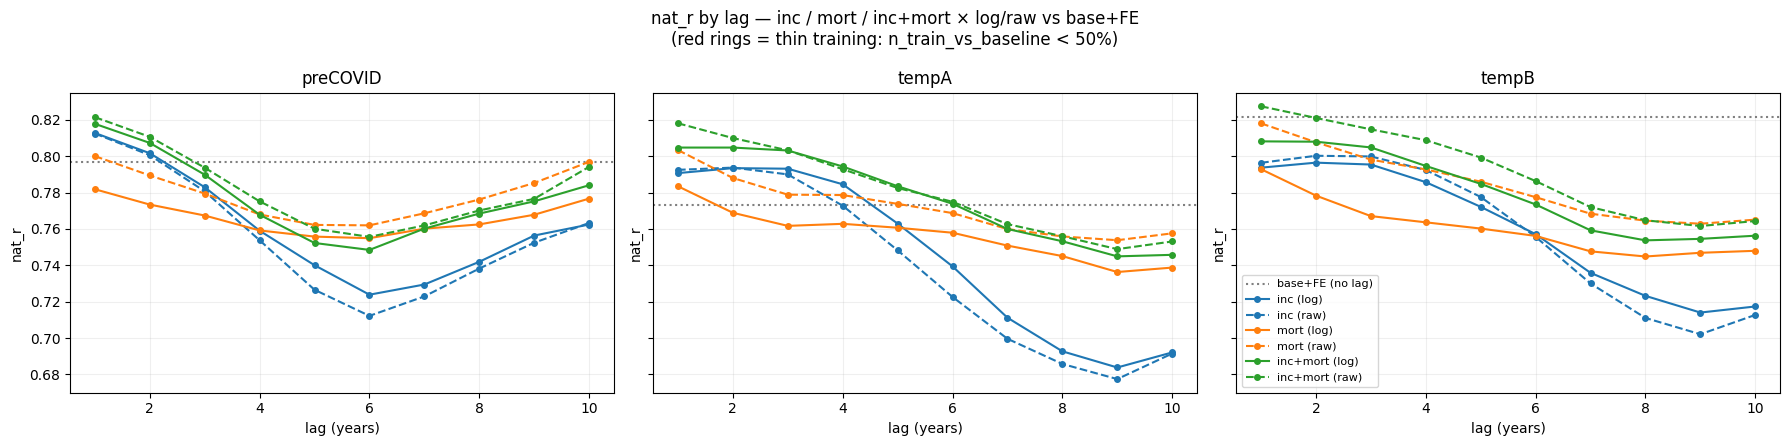

In [73]:
fig = plot_lag_sweep(results_A, metric="nat_r")   # B: FE line moves with lag
plt.show()

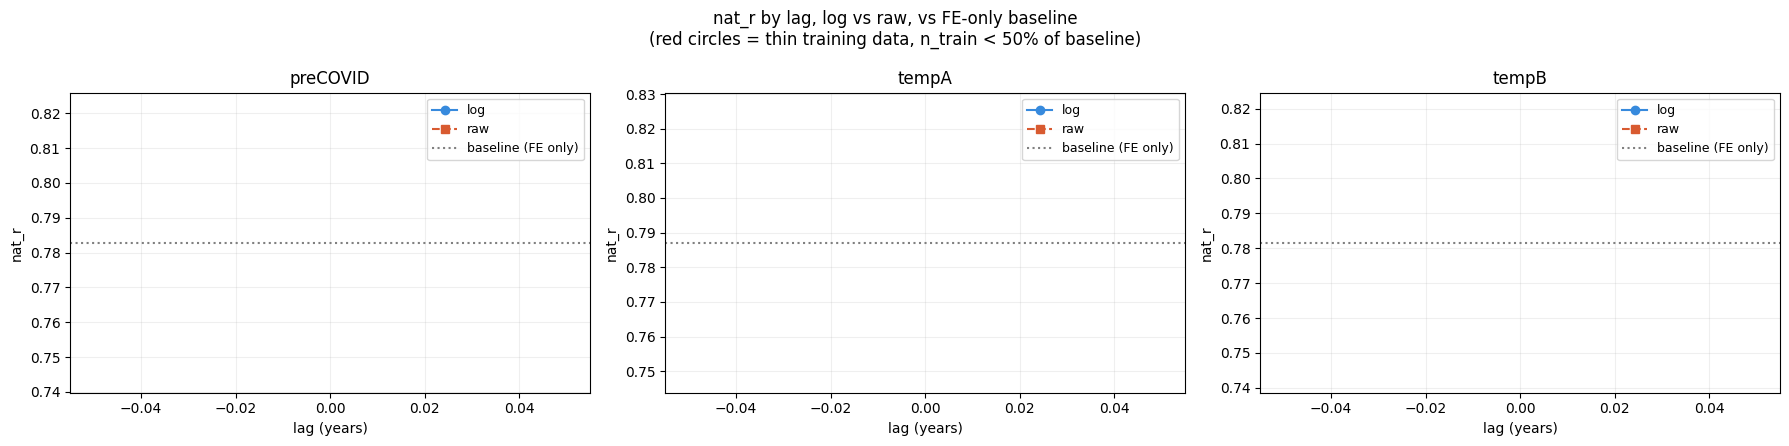

In [59]:
import matplotlib.pyplot as plt
import pandas as pd

# --- corrected fit_one per CC's finding: track n_train, not n_obs, for thin-data flag ---
def fit_one(frame, cols_needed, spec, outcome, window, factor_lam):
    sub = frame.dropna(subset=list(set(cols_needed + ["A0_location_id"]))).copy()
    sub["A0_af"] = sub["A0_location_id"].astype("category").cat.codes.astype("int64")
    res = fit.fit_predict(sub, spec, outcome, window, factor_lam=factor_lam)
    scores = metrics.score_predictions(res.predictions)
    if isinstance(window, fit.Temporal):
        n_train = int(((sub.year_id >= window.train_lo) & (sub.year_id <= window.train_hi)).sum())
    else:
        n_train = len(sub)
    return res, scores, n_train

# --- rerun sweep, now logging n_train ---
rows = []
for ev in windows:
    res, sc, n_train = fit_one(df, ["A0_location_id", "year_id"], baseline_spec, fit.PFPR, ev, FACTOR_LAM)
    rows.append({"lag": None, "transform": "none", "window": ev.name,
                 "n_train": n_train, "nat_r": sc["nat_r"], "r_sq": sc["r_sq"]})

for lag in LAGS:
    for transform, col in lag_cols(lag).items():
        if col not in df.columns:
            continue
        spec = (specs.Term(col, "smooth", 6), specs.Term("A0_af", "factor"))
        for ev in windows:
            res, sc, n_train = fit_one(df, [col, "A0_location_id", "year_id"], spec, fit.PFPR, ev, FACTOR_LAM)
            rows.append({"lag": lag, "transform": transform, "window": ev.name,
                         "n_train": n_train, "nat_r": sc["nat_r"], "r_sq": sc["r_sq"]})

results = pd.DataFrame(rows)

# --- flag thin-training cells instead of the old n_obs check ---
baseline_ntrain = results[results["lag"].isna()].set_index("window")["n_train"]
results["n_train_vs_baseline"] = results.apply(
    lambda r: r["n_train"] / baseline_ntrain[r["window"]], axis=1
)

# --- plot ---
def plot_lag_sweep(results, thin_thresh=0.5):
    windows = results["window"].unique()
    windows = [w for w in ["preCOVID", "tempA", "tempB"] if w in windows]  # fixed order

    fig, axes = plt.subplots(1, len(windows), figsize=(6 * len(windows), 4.5), sharey=False)
    if len(windows) == 1:
        axes = [axes]

    for ax, window in zip(axes, windows):
        sub = results[results["window"] == window]
        baseline_val = sub.loc[sub["lag"].isna(), "nat_r"].values[0]

        for transform, style in [("log", dict(color="#378ADD", linestyle="-", marker="o")),
                                  ("raw", dict(color="#D85A30", linestyle="--", marker="s"))]:
            tsub = sub[sub["transform"] == transform].sort_values("lag")
            ax.plot(tsub["lag"], tsub["nat_r"], label=transform, **style)

            # mark thin-training cells so a garbage point doesn't get read as a real result
            thin = tsub[tsub["n_train_vs_baseline"] < thin_thresh]
            if not thin.empty:
                ax.scatter(thin["lag"], thin["nat_r"], facecolors="none",
                           edgecolors="red", s=140, linewidths=1.5, zorder=5,
                           label="_nolegend_")

        ax.axhline(baseline_val, color="gray", linestyle=":", linewidth=1.5, label="baseline (FE only)")
        ax.set_title(window)
        ax.set_xlabel("lag (years)")
        ax.set_ylabel("nat_r")
        ax.legend(fontsize=9)
        ax.grid(alpha=0.2)

    fig.suptitle("nat_r by lag, log vs raw, vs FE-only baseline\n(red circles = thin training data, n_train < %d%% of baseline)" % int(thin_thresh*100))
    fig.tight_layout()
    return fig

fig = plot_lag_sweep(results)
fig.savefig("lag_sweep_nat_r.png", dpi=150, bbox_inches="tight")
plt.show()

In [61]:
results_df

,model,window,X,combo,log,n_train,n_obs,ssr,rmse,mae,r_sq,r,nat_n_obs,nat_ssr,nat_rmse,nat_mae,nat_r_sq,nat_r,n_train_vs_baseline
0,FE_model_tempA,tempA,0,None,False,117910,21972,26571.080097,1.099689,0.776624,0.810607,0.902915,21972,161.020171,0.085606,0.054456,0.614960,0.819073,1.000000
1,FE_model_tempB,tempB,0,None,False,64753,21972,24295.693032,1.051550,0.745449,0.826826,0.909636,21972,142.533997,0.080542,0.049179,0.659165,0.821808,1.000000
2,FE_model_preCOVID,preCOVID,0,None,False,124132,18121,23315.224889,1.134302,0.849678,0.825637,0.911494,18121,162.060172,0.094569,0.057080,0.611638,0.802665,1.000000
3,X1_inc_log_tempA,tempA,1,inc,True,109694,21971,43757.616117,1.411243,1.066814,0.688039,0.840802,21971,190.472859,0.093109,0.061021,0.544510,0.773349,0.930320
4,X1_inc_log_tempB,tempB,1,inc,True,64752,21971,40069.556674,1.350462,0.978452,0.714332,0.847278,21971,162.716101,0.086058,0.055279,0.610886,0.793914,0.999985
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268,X15_mort_raw_tempB,tempB,15,mort,False,30459,21972,48240.457142,1.481736,1.091355,0.656153,0.836982,21972,168.428498,0.087553,0.056683,0.597245,0.816316,0.470387
269,X15_mort_raw_preCOVID,preCOVID,15,mort,False,12338,18121,31029.967914,1.308578,0.974137,0.767942,0.877247,18121,160.763977,0.094190,0.056045,0.614744,0.819297,0.099394
270,X15_inc+mort_raw_tempA,tempA,15,inc+mort,False,6116,21972,49901.719856,1.507034,1.096600,0.644312,0.839503,21972,180.298980,0.090586,0.057981,0.568860,0.816730,0.051870
271,X15_inc+mort_raw_tempB,tempB,15,inc+mort,False,30459,21972,45841.460482,1.444423,1.061538,0.673252,0.846426,21972,166.174011,0.086965,0.055841,0.602636,0.818175,0.470387


In [60]:
print(len(results))                       # should be 273-ish if the sweep ran; probably 3 if only baseline ran
print([c for c in df.columns if "lag" in c][:10])   # empty or missing lagN_a0_mort_rate columns confirms it

3
[]


In [19]:
pd.DataFrame(rows).set_index("model")[["n_obs", "r_sq", "rmse", "nat_r"]]

,n_obs,r_sq,rmse,nat_r
model,,,,
lag_1_log,156007,0.778896,1.398042,0.833989
lag_1,156007,0.776949,1.404182,0.837689
lag_2_log,147974,0.770207,1.416107,0.825839
lag_2,147974,0.769010,1.419789,0.830372
lag_3_log,140083,0.763816,1.428378,0.817393
lag_3,140083,0.762425,1.432577,0.823018
lag_4_log,132170,0.754560,1.446721,0.808073
lag_4,132170,0.753316,1.450384,0.814324
lag_5_log,124500,0.746531,1.459314,0.798129


In [ ]:
# --- true lagged admin-0 pop-weighted mort_rate covariate (Version 1), X=10 ---
X = 10
log_flag = True

df_lag  = data.add_a0_lag(df, var="malaria_mort_rate", lag_years=X,
                          transform="log" if log_flag else None)   # log (not logit) — mort_rate is a small rate

lag_col = f"log_lag{X}_a0_mort_rate" if log_flag else f"lag{X}_a0_mort_rate"

# fair A/B: restrict EVERY model to rows where the lag exists (years >= 2000+X), so
# lag-vs-nolag is apples-to-apples on the same rows
df_cmp = df_lag.dropna(subset=[lag_col]).copy()
df_cmp["A0_af"] = df_cmp["A0_location_id"].astype("category").cat.codes.astype("int64")  # keep codes dense

base  = (specs.Term("malaria_suit", "mpi", 6), specs.Term("gdppc_mean", "mpd", 6),
         specs.Term("mal_DAH_total_per_capita", "mpd", 6), specs.Term("logit_relative_humidity", "mpi", 6))
lag_t = specs.Term(lag_col, "mpi", 6)
FE_t  = specs.Term("A0_af", "factor")

rows, fits = [], {}
for use_lag in [False, True]:
    for include_FE in [False, True]:
        spec = base + ((lag_t,) if use_lag else ()) + ((FE_t,) if include_FE else ())
        res  = fit.fit_predict(df_cmp, spec, fit.PFPR, "IS")
        name = f"{'lag' if use_lag else 'nolag'}_{'FE' if include_FE else 'noFE'}"
        fits[name] = res
        rows.append({"model": name, **metrics.score_predictions(res.predictions)})
pd.DataFrame(rows).set_index("model")[["n_obs", "r_sq", "rmse", "nat_r"]]


In [ ]:
coef_df.sort_values("coef")
# save when ready (pick a real output dir, not scratch):
# coef_df.to_parquet("<output_dir>/pfpr_effects.parquet", index=False)
# pval_df.to_parquet("<output_dir>/pfpr_term_pvalues.parquet", index=False)

### Goal #1 — drop the country fixed effects / vary the formula

Drop `A0_af` for no fixed effects, or pass `factor_lam` small to shrink it. Compare temporal-OOS `nat_r`.

In [ ]:
no_fe_spec = tuple(t for t in pfpr_spec if t.col != "A0_af")

variants = {
    "with FE (penalized)": dict(spec=pfpr_spec, factor_lam=None),
    "with FE (lam->0)":    dict(spec=pfpr_spec, factor_lam=1e-3),
    "no FE":               dict(spec=no_fe_spec, factor_lam=None),
}
rows = []
for name, kw in variants.items():
    res = fit.fit_predict(df, kw["spec"], fit.PFPR, fit.TEMP_A, factor_lam=kw["factor_lam"])
    rows.append({"variant": name, **metrics.score_predictions(res.predictions)})
pd.DataFrame(rows).set_index("variant")[["n_obs", "r_sq", "nat_r"]]

## Phase 3 — downstream chain (PfPR -> 2023 shift -> incidence / mortality)

Load with `row_filter='final'` (adds the log-rate responses). `shift.downstream_chain` fits PfPR,
shifts to the observed 2023 anchor, feeds shifted PfPR into the inc/mort models (production RHS
`s(logit_pfpr, mpi, k=10) + log_gdppc_mean + A0`), and (with `shift_downstream=True`) anchors
inc/mort to their observed 2023 values too.

**Open decision:** `shift_downstream` defaults to `True` (mirror production); set `False` for raw output.

In [ ]:
dff = data.load_modeling_data(row_filter="final")
result = shift.downstream_chain(dff, pfpr_spec, fit.TEMP_A)
shift.chain_score_table(result)[["outcome", "evaluation", "n_obs", "r_sq", "nat_r"]]

### Compare a PfPR formulation's effect on the downstream outcomes

Swap `pfpr_spec` for any candidate and re-run the chain — the inc/mort scores show how the PfPR
formula propagates to the outcomes you forecast.

*Phase 4 (next) will add `forecast.py`: pick a draw + climate scenario and run trajectories to 2100.*